In [1]:
!pip install ultralytics
!pip install matplotlib opencv-python
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00


In [2]:
!pip install shap

In [3]:
import torch
import numpy as np
import shap
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/best.pt")

def predict_wrapper(images):
    # SHAP এর জন্য একটি প্রেডিকশন ফাংশন যা প্রোবাবিলিটি রিটার্ন করবে
    final_preds = []
    for img in images:
        # মডেলকে ইনপুট দেওয়ার আগে প্রসেসিং
        results = model.predict(img, conf=0.1, verbose=False)
        if len(results[0].boxes) > 0:
            conf = results[0].boxes.conf.cpu().numpy().max()
            final_preds.append([1 - conf, conf]) # [Normal, Fractured]
        else:
            final_preds.append([1.0, 0.0])
    return np.array(final_preds)

# একটি টেস্ট ইমেজ লোড করা
img_path = "/kaggle/input/datasets/pmtasrifulislam/yolo-v8l-best-model/archive/dataset/train/images/115_jpg.rf.e502e3b728f83a17a782892ab3edae06.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224)) # SHAP দ্রুত করার জন্য সাইজ কমানো হয়েছে

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [15:33, 933.74s/it]              


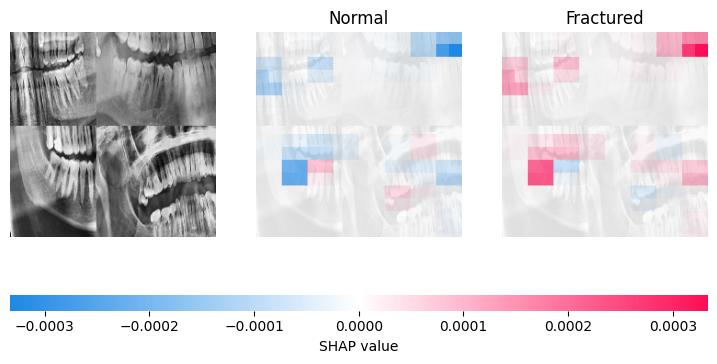

In [5]:
# স্যাম্পল ডেটা হিসেবে ইমেজটি ব্যবহার করা
masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))

# এক্সপ্লেইনার তৈরি (Partition explainer সাধারণত ইমেজের জন্য ভালো)
explainer = shap.Explainer(predict_wrapper, masker, output_names=['Normal', 'Fractured'])

# ব্যাখ্যা জেনারেট করা (এটি কিছুটা সময় নিতে পারে)
shap_values = explainer(np.array([img_resized]), max_evals=500, batch_size=50)

# রেজাল্ট প্লট করা
shap.image_plot(shap_values)